# VNExpress News Data Overview
VNEXpress là một trong những trang báo điện tử lớn nhất tại Việt Nam, cung cấp tin tức về nhiều lĩnh vực như chính trị, kinh tế, xã hội, thể thao, giải trí và công nghệ. Dưới đây là một số thông tin về dữ liệu từ VNExpress:
* 1. Nguồn dữ liệu: VNExpress
* 2. Thời gian thu thập: Từ tháng 1 năm 2026 đến tháng 3 năm 2026
* 3. Các lĩnh vực tin tức: Công nghệ, Khoa học, Sức khoẻ, Thể thao, Giải trí, Chính trị, Kinh tế, Xã hội,...
* 4. Số lượng bài viết: Khoảng 100.000 bài viết

Notebook này thực hiện khảo sát và thống kê sơ bộ dữ liệu thu thập từ VNExpress, tập trung vào hai nhóm bài viết: 
* "Sức khoẻ" và "Giải trí".

## Dữ liệu bao gồm các trường
* `title`: Tiêu đề bài viết
* `description`: Mô tả ngắn gọn 
* `date`: Ngày giờ xuất bản bài viết
* `category`: Thể loại bài viết (Ví dụ: Phim, Nhạc, Hô hấp, Thần kinh,...)
* `thumbnail`: Đường dẫn đến hình ảnh đại diện bài viết
* `content`: Nội dung bài viết
* `author`: Tác giả bài viết
* `tags`: Các thẻ liên quan đến bài viết
* `group`: Danh mục bài viết (Sức khoẻ, Giải trí)
* `nums_of_comments`: Số lượng bình luận bài viết
* `url`: Đường dẫn đến bài viết




## 1. Import các thư viện cần thiết

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import os
import re
from collections import Counter

sns.set(style="whitegrid")

pd.set_option('display.max_columns', None)

## 2. Đọc và tìm hiểu dữ liệu

### 2.1 Đọc dữ liệu từ file CSV

In [12]:
DATA_PATH = "../data/raw_data/"

df = pd.read_csv(DATA_PATH + "vnexpress_raw_data.csv", encoding="utf-8")

print("Kích thước dataset:", df.shape)

Kích thước dataset: (1236, 11)


### 2.2 Xem vài dòng dữ liệu đầu

In [13]:
df.head()

,title,description,date,content,thumbnail,author,tags,group,category,nums_of_comments,url
0,5 gia vị hỗ trợ giảm hình thành cục máu đông,Tỏi chứa allicin có thể hạn chế hình thành cục...,"Thứ tư, 11/3/2026, 08:30 (GMT+7)","Cùng với tim, mạch máu là một phần của hệ tuần...",https://i1-suckhoe.vnecdn.net/2026/03/10/image...,NaN,"cục máu đông, thực phẩm, dinh dưỡng",Sức khỏe,Các bệnh,0,https://vnexpress.net/5-gia-vi-ho-tro-giam-hin...
1,Sắc vóc bạn gái Liên Bỉnh Phát,Ngọc Kayla - cựu thành viên nhóm Mắt Ngọc - có...,"Chủ nhật, 25/1/2026, 19:00 (GMT+7)",Ngọc Kayla sánh đôi bạn trai dự buổi công chiế...,https://i1-giaitri.vnecdn.net/2026/01/24/ngoc-...,NaN,"liên bỉnh phát, ngọc kayla",Giải trí,Thời trang,0,https://vnexpress.net/sac-voc-ban-gai-lien-bin...
2,Midu cùng dàn sao dự thảm đỏ 'Tinh hoa Việt',TP HCMDiễn viên Midu cùng dàn sao Việt chưng d...,"Thứ hai, 26/1/2026, 21:07 (GMT+7)","Midu diện áo dài xuyên thấu, họa tiết hoa 3D d...",https://i1-giaitri.vnecdn.net/2026/01/26/z7470...,NaN,"tp hcm, tinh hoa việt, midu, dàn sao",Giải trí,Giới sao,0,https://vnexpress.net/midu-cung-dan-sao-du-tha...
3,Lý Liên Kiệt: 'Từng rất mệt vì cố giống Hoàng ...,Diễn viên gốc Hoa Lý Liên Kiệt nói trước đây í...,"Thứ hai, 9/3/2026, 16:29 (GMT+7)","TheoCNA, sao võ thuật nói về công việc, đời số...",https://i1-giaitri.vnecdn.net/2026/03/09/ly-li...,NaN,"lý liên kiệt, sao võ thuật, hoàng phi hồng, co...",Giải trí,Giới sao,0,https://vnexpress.net/ly-lien-kiet-tung-rat-me...
4,Italy chi 35 triệu USD mua tranh của Caravaggio,Chính phủ Italy mua bức tranh do Caravaggio vẽ...,"Thứ năm, 12/3/2026, 21:23 (GMT+7)","TheoAP, thông tin được Bộ Văn hóa Italy công b...",https://i2-vnexpress.vnecdn.net/2026/03/12/34x...,NaN,"caravaggio, italy, portrait of monsignor maffe...",Giải trí,Sân khấu - Mỹ thuật,0,https://vnexpress.net/italy-chi-35-trieu-usd-m...


### 2.3 Thông tin các cột dữ liệu

In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1236 entries, 0 to 1235
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   title             1231 non-null   str    
 1   description       1231 non-null   str    
 2   date              1232 non-null   str    
 3   content           1231 non-null   str    
 4   thumbnail         1235 non-null   str    
 5   author            0 non-null      float64
 6   tags              1231 non-null   str    
 7   group             1222 non-null   str    
 8   category          1222 non-null   str    
 9   nums_of_comments  1236 non-null   int64  
 10  url               1236 non-null   str    
dtypes: float64(1), int64(1), str(9)
memory usage: 106.3 KB


### 2.4 Kiểm tra dữ liệu thiếu

In [15]:
missing_values = df.isnull().sum()

missing_percentage = (missing_values / len(df)) * 100

missing_df = pd.DataFrame({
    "Missing Values": missing_values,
    "Missing (%)": missing_percentage
})

missing_df.sort_values(by="Missing Values", ascending=False)

,Missing Values,Missing (%)
author,1236,100.000000
group,14,1.132686
category,14,1.132686
title,5,0.404531
description,5,0.404531
content,5,0.404531
tags,5,0.404531
date,4,0.323625
thumbnail,1,0.080906
nums_of_comments,0,0.000000


### 2.5 Thống kê mô tả

In [16]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
author,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
nums_of_comments,1236.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 3. Phân bố dữ liệu

### 3.1 Số lượng bài viết theo nhóm

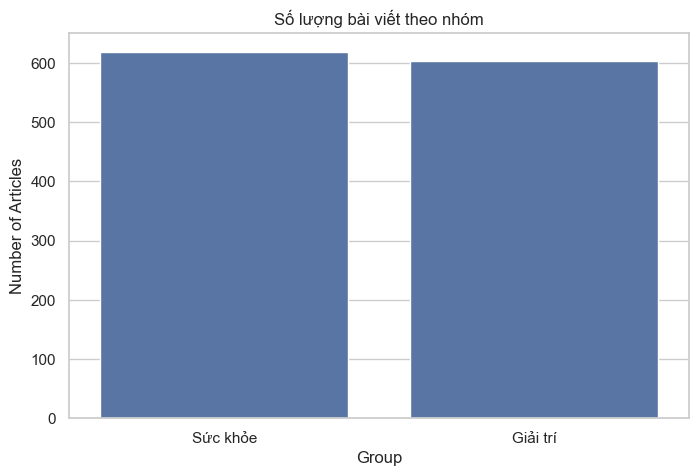

In [17]:
plt.figure(figsize=(8,5))

group_counts = df["group"].value_counts()

sns.barplot(
    x=group_counts.index,
    y=group_counts.values
)

plt.title("Số lượng bài viết theo nhóm")
plt.xlabel("Group")
plt.ylabel("Number of Articles")

plt.show()

### 3.2 Số lượng bài theo category

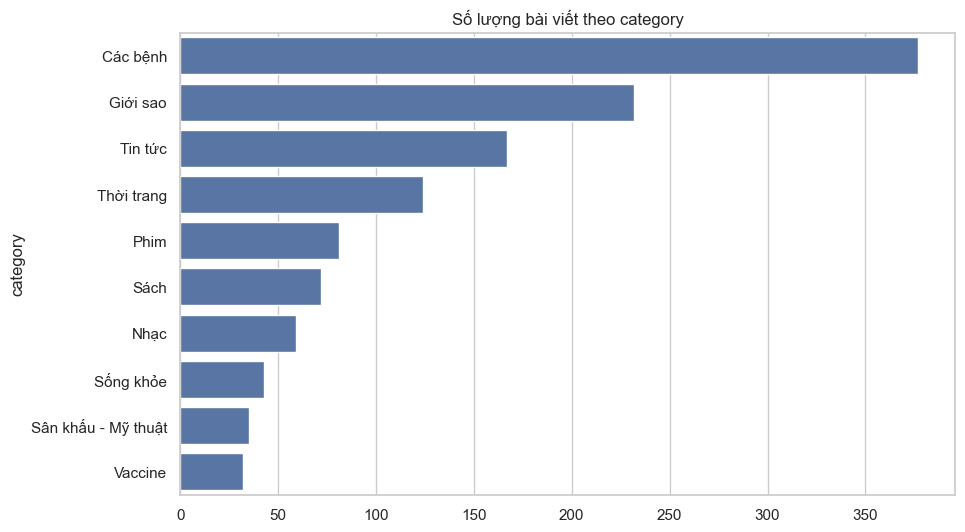

In [18]:
plt.figure(figsize=(10,6))

category_counts = df["category"].value_counts()

sns.barplot(
    y=category_counts.index,
    x=category_counts.values
)

plt.title("Số lượng bài viết theo category")

plt.show()

### 3.3 Phân bố số lượng bình luận

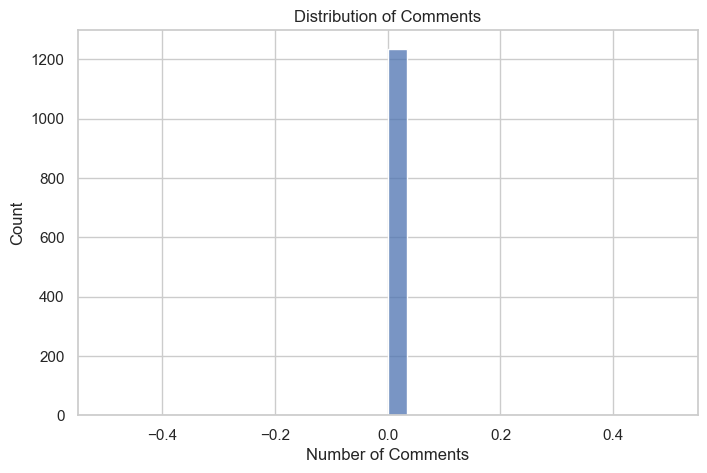

In [19]:
plt.figure(figsize=(8,5))

sns.histplot(df["nums_of_comments"], bins=30)

plt.title("Distribution of Comments")

plt.xlabel("Number of Comments")

plt.show()

### 3.4 Phân tích độ dài title và content

In [20]:
df["title_length"] = df["title"].fillna("").apply(lambda x: len(x.split()))
df["content_length"] = df["content"].fillna("").apply(lambda x: len(x.split()))

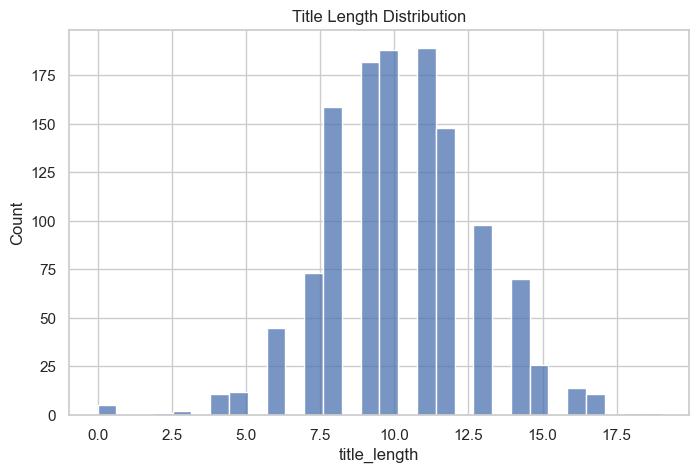

In [21]:
plt.figure(figsize=(8,5))

sns.histplot(df["title_length"], bins=30)

plt.title("Title Length Distribution")

plt.show()

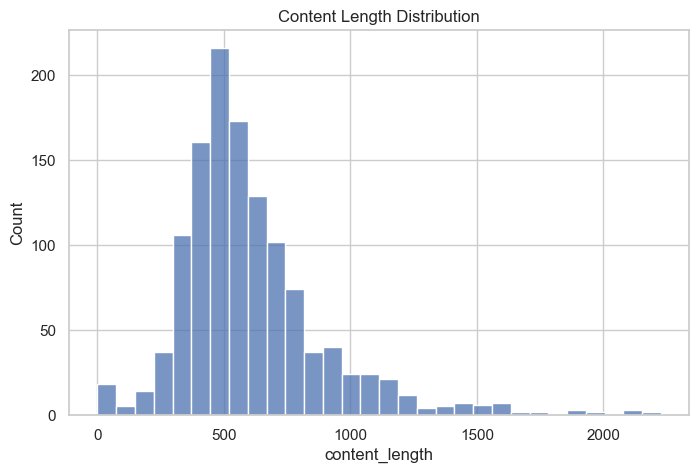

In [22]:
plt.figure(figsize=(8,5))

sns.histplot(df["content_length"], bins=30)

plt.title("Content Length Distribution")

plt.show()

### 3.5 Kiểm tra bài viết bất thường

In [23]:
df.sort_values("content_length", ascending=False).head()

,title,description,date,content,thumbnail,author,tags,group,category,nums_of_comments,url,title_length,content_length
628,'Bóng đá Việt Nam' (kỳ 1): Huấn luyện cầu thủ ...,"Giai đoạn đất nước còn chiến tranh, thế hệ cầu...","Thứ hai, 26/1/2026, 10:39 (GMT+7)",Ấn phẩmBóng đá Việt Nam (1896-2025): Ký ức và ...,https://i1-giaitri.vnecdn.net/2026/01/14/dd3f2...,NaN,"đội thể công, bóng đá việt nam, bóng đá việt n...",Giải trí,Sách,0,https://vnexpress.net/bong-da-viet-nam-ky-1-hu...,13,2228
138,'Bóng đá Việt Nam' (kỳ 2): Trận cầu mừng 25 nă...,"Đội Thể Công gỡ hòa, ghi bàn, lội ngược dòng s...","Thứ ba, 27/1/2026, 14:56 (GMT+7)",Ấn phẩmBóng đá Việt Nam (1896-2025): Ký ức và ...,https://i1-giaitri.vnecdn.net/2026/01/14/1a9ef...,NaN,"thể công, bóng đá việt nam, tác giả đặng hoàng...",Giải trí,Sách,0,https://vnexpress.net/bong-da-viet-nam-ky-2-tr...,13,2194
350,Đạo diễn Nguyễn Hoàng Điệp: Con trẻ sẽ đọc sác...,"Đạo diễn Nguyễn Hoàng Điệp cho rằng không ""thầ...","Thứ tư, 25/2/2026, 12:13 (GMT+7)","Bên cạnh công việc làm phim, đạo diễn Nguyễn H...",https://i1-giaitri.vnecdn.net/2026/02/13/ff4a2...,NaN,"đạo diễn nguyễn hoàng điệp, đọc sách, tủ sách ...",Giải trí,Sách,0,https://vnexpress.net/dao-dien-nguyen-hoang-di...,16,2152
951,Tự truyện Bob Iger - đằng sau thương vụ tỷ USD,"Khi đọc ''The Ride of a Lifetime'', có lúc tôi...","Thứ năm, 12/3/2026, 19:07 (GMT+7)","* Bài cảm nhận cho chuyên mục ""Cuốn sách tôi y...",https://i1-giaitri.vnecdn.net/2026/03/12/nxbtr...,NaN,"tự truyện của bob iger, cuốn sách tôi yêu",Giải trí,Sách,0,https://vnexpress.net/tu-truyen-bob-iger-dang-...,11,2102
21,Sách của nhà sư Thích Pháp Hòa (kỳ một): dạy c...,"Trong sách ""Lá hoa trên đường về"", nhà sư Thíc...","Thứ bảy, 21/2/2026, 10:10 (GMT+7)",SáchLá hoa trên đường vềtuyển tập những vấn đá...,https://i1-giaitri.vnecdn.net/2026/02/16/thich...,NaN,nhà sư thích pháp hòa,Giải trí,Sách,0,https://vnexpress.net/sach-cua-nha-su-thich-ph...,12,2085


## 4. Nhận xét về dữ liệu raw

Qua quá trình phân tích dữ liệu thô:

- Dataset gồm các bài viết từ hai chuyên mục:
  - Sức khỏe
  - Giải trí

- Một số vấn đề phát hiện:
  - Có thể tồn tại dữ liệu thiếu
  - Định dạng ngày chưa chuẩn
  - Văn bản chưa được chuẩn hóa
  - Có thể có bài trùng lặp

→ Vì vậy cần bước **data cleaning** để:

- Loại bỏ duplicates
- Chuẩn hóa text
- Chuẩn hóa date
- Xử lý missing values

## 5. Định hướng bài toán

Từ dữ liệu này có thể xây dựng các bài toán:

### Hướng 1: Dự đoán số lượng bình luận
- Input: title_length, content_length, category...
- Output: nums_of_comments

### Hướng 2: Phân loại bài viết
- Phân loại bài viết thuộc nhóm:
  - Sức khỏe
  - Giải trí

### Hướng 3: Phân tích xu hướng nội dung
- Phân tích chủ đề phổ biến
- Phân tích độ dài bài viết